In [ ]:
!pip -q install scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
# ✅ CHANGE ONLY THESE
TRAIN_DIR = "/content/drive/MyDrive/Capstone Dataset/Guava_Leaf_Dieases/Train"
TEST_DIR  = "/content/drive/MyDrive/Capstone Dataset/Guava_Leaf_Dieases/Test"

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS_HEAD = 5
EPOCHS_FINETUNE = 25
LR_HEAD = 1e-3
LR_FINETUNE = 1e-5

In [ ]:
# 4) Load Dataset (Already split: Train/Test)
#    -> Train folder = training set
#    -> Test folder  = validation set + also used as final test evaluation (as you requested)
# =========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

# Keep a deterministic copy for metrics (confusion matrix/ROC need fixed order)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# ✅ Safety: ensure TEST has same class order/names as TRAIN
if val_ds.class_names != class_names:
    raise ValueError(
        "Class name/order mismatch between Train and Test folders.\n"
        f"Train: {class_names}\nTest : {val_ds.class_names}\n"
        "Fix folder class subdirectory names so they match exactly."
    )

Found 4600 files belonging to 5 classes.
Found 1150 files belonging to 5 classes.
Found 1150 files belonging to 5 classes.
Classes: ['Anthracnose', 'Canker', 'Dot', 'Healthy', 'Rust']


In [ ]:
# 5) Data Pipeline Optimization
# =========================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
# 6) Data Augmentation (train only)
# =========================
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1),
], name="data_augmentation")

In [ ]:
# 7) Build Pretrained Model
# =========================
base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_aug(inputs)              # augmentation only affects training (Keras handles this automatically)
x = preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 8) Train Head (Frozen base)
# =========================
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks)

Epoch 1/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 1076s 2s/step - accuracy: 0.4723 - loss: 1.2669 - val_accuracy: 0.6435 - val_loss: 0.9200 - learning_rate: 0.0010
Epoch 2/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.7371 - loss: 0.7557 - val_accuracy: 0.6739 - val_loss: 0.8691 - learning_rate: 0.0010
Epoch 3/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.7966 - loss: 0.6196 - val_accuracy: 0.6678 - val_loss: 0.8736 - learning_rate: 0.0010
Epoch 4/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.7974 - loss: 0.6074 - val_accuracy: 0.6748 - val_loss: 0.8559 - learning_rate: 0.0010
Epoch 5/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.8113 - loss: 0.5505 - val_accuracy: 0.6991 - val_loss: 0.8451 - learning_rate: 0.0010


In [ ]:
# 9) Fine-tuning (Unfreeze last layers)
# =========================
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINETUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE, callbacks=callbacks)

Epoch 1/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 32s 128ms/step - accuracy: 0.7512 - loss: 0.6939 - val_accuracy: 0.7496 - val_loss: 0.7742 - learning_rate: 1.0000e-05
Epoch 2/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.8016 - loss: 0.5838 - val_accuracy: 0.7409 - val_loss: 0.7844 - learning_rate: 1.0000e-05
Epoch 3/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.8088 - loss: 0.5408 - val_accuracy: 0.7478 - val_loss: 0.7586 - learning_rate: 1.0000e-05
Epoch 4/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.8149 - loss: 0.5214 - val_accuracy: 0.7461 - val_loss: 0.7560 - learning_rate: 1.0000e-05
Epoch 5/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.8181 - loss: 0.4801 - val_accuracy: 0.7504 - val_loss: 0.7698 - learning_rate: 1.0000e-05
Epoch 6/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.8324 - loss: 0.4792 - val_accuracy: 0.7513 - val_loss: 0.7704 - learning_rate: 1.0000e-05
Epoch 7/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 10

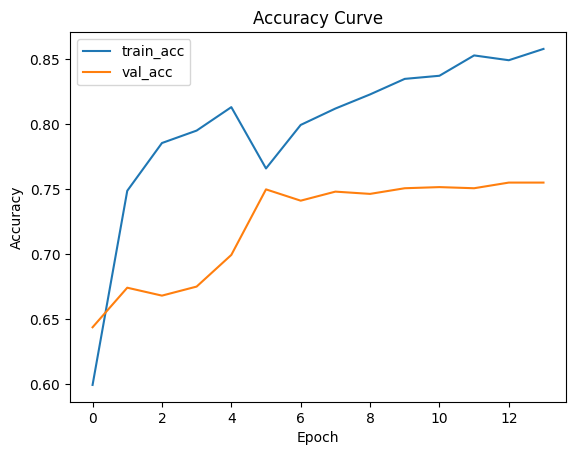

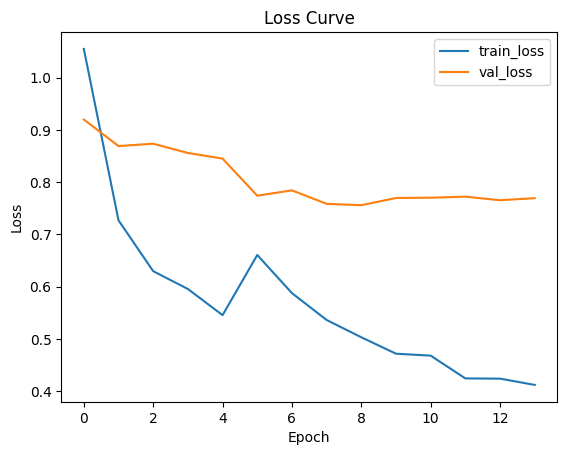

In [ ]:
# 10) Plot Training Curves
# =========================
def plot_curves(h1, h2):
    acc = h1.history.get("accuracy", []) + h2.history.get("accuracy", [])
    val_acc = h1.history.get("val_accuracy", []) + h2.history.get("val_accuracy", [])
    loss = h1.history.get("loss", []) + h2.history.get("loss", [])
    val_loss = h1.history.get("val_loss", []) + h2.history.get("val_loss", [])

    plt.figure()
    plt.plot(acc, label="train_acc")
    plt.plot(val_acc, label="val_acc")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(loss, label="train_loss")
    plt.plot(val_loss, label="val_loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_curves(h1, h2)

In [ ]:
# 11) Evaluate on Test Set (same as your TEST folder)
# =========================
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


Test Accuracy: 0.7461 | Test Loss: 0.7560


In [ ]:
# 12) Predictions
# =========================
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

In [ ]:
# 13) Classification Report
# =========================
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Classification Report:
              precision    recall  f1-score   support

 Anthracnose     0.6607    0.9652    0.7845       230
      Canker     0.8782    0.7522    0.8103       230
         Dot     0.5450    0.4478    0.4916       230
     Healthy     0.7761    0.8739    0.8221       230
        Rust     0.9408    0.6913    0.7970       230

    accuracy                         0.7461      1150
   macro avg     0.7602    0.7461    0.7411      1150
weighted avg     0.7602    0.7461    0.7411      1150



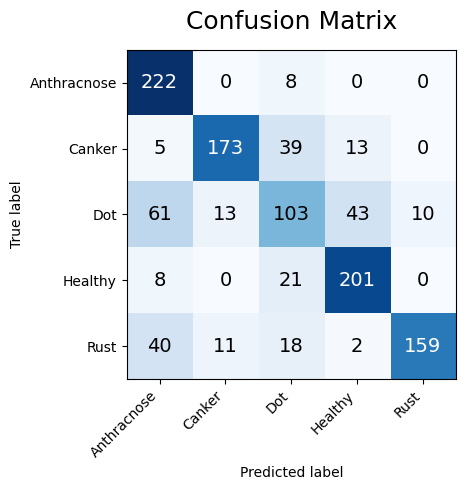

In [ ]:
# 14) Confusion Matrix (EXACT style as provided image)
# =========================
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))

# Blue-style matrix (same as your image)
im = ax.imshow(cm, cmap=plt.cm.Blues)

ax.set_title("Confusion Matrix", fontsize=18, pad=15)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

# Add numbers inside cells
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            fontsize=14,
            color="white" if cm[i, j] > thresh else "black"
        )

# ❌ No colorbar (important)
ax.figure.colorbar(im).remove()

ax.grid(False)
plt.tight_layout()
plt.show()


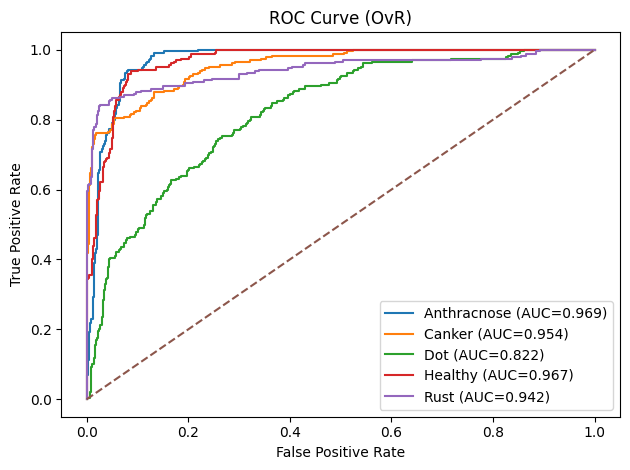

In [ ]:
# 15) ROC Curve (One-vs-Rest)
# =========================
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 17) Save Model
import os
os.makedirs("/content/drive/MyDrive/Capstone Models", exist_ok=True)

model.save("/content/drive/MyDrive/Capstone Models/EfficientNetB0_leaf.keras")
print("Model saved successfully.")

Model saved successfully.
